In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [20]:
# reading the file 
# read.csv will read csv file and transform it into dataframe 
df = pd.read_csv ("energy_heating_cooling.csv")

# a fucnction that shows the first 10 rows of the dataframe 
# this will help us see how the data in the file is being sorted 
print (df.head (10))

# now we will change column name to be more clear 
# first we will make a dictioanry and connect the current column name with the new one 

col_new_names = {
    'X1' : 'Surface_Area',
    'X2' : 'Relative_Compactness',
    'X3' : 'Roof_Area',
    'X4' : 'Wall_Area',
    'X5' : 'Orientation',
    'X6' : 'Overall_Height',
    'X7' : 'Glazing_Area',
    'X8' : 'Glazing_Area_Distribution',
    'Y1' : 'Heating_Load',
    'Y2' : 'Cooling_Load'

}

# now we will use rename function in pandas
# inplace = the new changes will happen on cuttrnet df  
df.rename (columns= col_new_names , inplace = True  )

# checking the new column names 
print (df.head ())


      X1      X2      X3     X4     X5   X6   X7          X8     Y1     Y2
0  514.5  100.00  110.25  294.0  North  7.0  0.0  No glazing  15.55  21.33
1  514.5  100.00  110.25  294.0   East  7.0  0.0  No glazing    NaN    NaN
2  514.5  100.00  110.25  294.0  South  7.0  0.0  No glazing  15.55  21.33
3  514.5  100.00  110.25  294.0   West  7.0  0.0  No glazing  15.55  21.33
4  563.5    0.90  122.50  318.5  North  7.0  0.0  No glazing  20.84  28.28
5  563.5    0.90  122.50  318.5   East  7.0  0.0  No glazing  21.46  25.38
6  563.5    0.90  122.50  318.5  South  7.0  0.0  No glazing  20.71  25.16
7  563.5    0.90  122.50  318.5   West  7.0  0.0  No glazing  19.68  29.60
8  588.0    0.86  147.00  294.0  North  7.0  0.0  No glazing  19.50  27.30
9  588.0    0.86  147.00  294.0   East  7.0  0.0  No glazing  19.95  21.97
   Surface_Area  Relative_Compactness  Roof_Area  Wall_Area Orientation  \
0         514.5                 100.0     110.25      294.0       North   
1         514.5          

In [21]:

#  exploration of the dataset

print ('\n Data Shape :  ' , df.shape)
print ('\n Data Types :  \n' , df.dtypes )
# df.info should viwe the number of rows and columns & data types & non null values & uses of memory 
print ('\n Data Information :  ' )
df.info()
# shows the count, min, max, avrg ... 
print ('\n Numerical Summary Statistics: ' , df.describe())
print ('\n the Data Size : ', df.size)


 Data Shape :   (798, 10)

 Data Types :  
 Surface_Area                 float64
Relative_Compactness         float64
Roof_Area                    float64
Wall_Area                    float64
Orientation                      str
Overall_Height               float64
Glazing_Area                 float64
Glazing_Area_Distribution        str
Heating_Load                 float64
Cooling_Load                 float64
dtype: object

 Data Information :  
<class 'pandas.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Surface_Area               798 non-null    float64
 1   Relative_Compactness       798 non-null    float64
 2   Roof_Area                  798 non-null    float64
 3   Wall_Area                  798 non-null    float64
 4   Orientation                798 non-null    str    
 5   Overall_Height             798 non-null    float64
 6   G

In [22]:

# cleaning the data 

# get rid of any duplicated recordes 
# df.duplicated return a df indexes with a boolen series  
print ("\nshow duplicated recordes : \n" , df[df.duplicated()])
print ("\n Number of duplicated recordes : ", df.duplicated().sum())

# now to remove the duplicated recordes 

df.drop_duplicates(inplace= True)

# check that all duplicates had been droped 
print ("\nThe number of remaining duplicates ",df.duplicated().sum())
# if it is = zero all the duplicates recoreds was  dropped successfuly 

# Standardizing the format

# the orientation column should only contain 4 unique values 
# to check 
print ('\n\nUniqe values for Orientation column : ', df['Orientation'].unique())


print ('The number of the current vlaues in the orientaion column is : ', len (df['Orientation'].unique()))

# strip is a fucntion delete the extra spaces before and after
# capitalize make all the  letters small except the first make it capitale letter 
df['Orientation'] =df['Orientation'].str.strip().str.capitalize()

print ('\n \nCheck the Orientaion values after cleaning : ', df['Orientation'].unique())
print ('\nThe number of  vlaues in the orientaion column after cleaning : ', len (df['Orientation'].unique()))
# if the number become 4 , it will mean the cleaning process for orientation column worked



# check the unique vales in Glazing_Area_Distribution
print ('\n \nCheck the Glazing_Area_Distribution values after cleaning : ', df['Glazing_Area_Distribution'].unique())
# the values in this column does not need cleaning 




show duplicated recordes : 
      Surface_Area  Relative_Compactness  Roof_Area  Wall_Area Orientation  \
768         759.5                  0.66     220.50      318.5       South   
769         784.0                  0.64     220.50      343.0        West   
770         588.0                  0.86     147.00      294.0       North   
771         612.5                  0.82     147.00      318.5       North   
772         514.5                  0.98     110.25      294.0       South   
773         686.0                  0.74     220.50      245.0        East   
774         514.5                  0.98     110.25      294.0       South   
775         759.5                  0.66     220.50      318.5       South   
776         710.5                  0.71     220.50      269.5        East   
777         637.0                  0.79     147.00      343.0        West   
778         612.5                  0.82     147.00      318.5       North   
779         612.5                  0.82     14

In [23]:
# now cleaning Relative_Compactness  column data 
# the values in this column should be between 0-1 

df.loc[df['Relative_Compactness'] > 1 , 'Relative_Compactness'] = 1

# to check if now all the Relative_Compactness are now in the range 
print ('\n The minimum value in Relative_Compactness  column is :  ' , df['Relative_Compactness'].min())

print ('\n The maximum value in Relative_Compactness  column is :  ' , df['Relative_Compactness'].max())



# now checking the number of null values
# isna return a dataframe of boolen values and isna.sum return the number of null values in each column  
print ("\n    Missing values for each column\n", df.isna().sum())
print ("\nthe totla number for missng values : ", df.isna().sum().sum())

# Categorical Encoding 

# we can not make a numeriacla operations on string values
# so the string values in Orientation and Glazing_Area_Distribution should be converted 

# we will make a copy beacue the oringin dataframe will be needed in visulization purposes

df_copy = df.copy()

# we will use label encoded 
from sklearn.preprocessing import LabelEncoder
# the origin encoded will stay at the data 
df['Orientation_Encoded'] = LabelEncoder().fit_transform(df['Orientation'])
df['Glazing_Area_Distribution_Encoded'] = LabelEncoder().fit_transform(df['Glazing_Area_Distribution'])


df_encoded = df
# check on the changes that happen after encoded 

print (df_encoded.head(3))






 The minimum value in Relative_Compactness  column is :   0.62

 The maximum value in Relative_Compactness  column is :   1.0

    Missing values for each column
 Surface_Area                  0
Relative_Compactness          0
Roof_Area                     0
Wall_Area                     0
Orientation                   0
Overall_Height                0
Glazing_Area                  0
Glazing_Area_Distribution     0
Heating_Load                 41
Cooling_Load                 41
dtype: int64

the totla number for missng values :  82
   Surface_Area  Relative_Compactness  Roof_Area  Wall_Area Orientation  \
0         514.5                   1.0     110.25      294.0       North   
1         514.5                   1.0     110.25      294.0        East   
2         514.5                   1.0     110.25      294.0       South   

   Overall_Height  Glazing_Area Glazing_Area_Distribution  Heating_Load  \
0             7.0           0.0                No glazing         15.55   
1         

In [24]:

#  Heating Load  
# # to train the model we wil need the rows that have not null  value
obs_heating = df_encoded['Heating_Load'].notna()

predictor_cols_h = ['Surface_Area', 'Relative_Compactness', 'Roof_Area', 'Wall_Area', 
                    'Overall_Height', 'Glazing_Area', 'Orientation_Encoded', 'Glazing_Area_Distribution_Encoded']
# find the correlation 
# this is very important line which is responcaple for measuring the correlations between the predictor_cols and the target 
corr_h = df_encoded.loc[obs_heating , predictor_cols_h + ['Heating_Load'] ].corr()['Heating_Load'].drop('Heating_Load')
# take the top 2 correlation columns and save their values in a list 
top2_features_h = corr_h.abs().sort_values(ascending= False).index[0:2].tolist()

print("\n \n \n Top correlated features with Heating_Load:", top2_features_h)

# train the model 

# train the LinearRegression model 
x_train_h = df_encoded.loc[obs_heating , top2_features_h].values
y_train_h = df_encoded.loc[obs_heating , ['Heating_Load']].values

model_h = LinearRegression()

model_h.fit (x_train_h , y_train_h)

# predict the values 
# now making the model predicting the vlaues 
# saving the missing values in a variable 
missing_h = df_encoded['Heating_Load'].isna()
# checking if there are any missing values 
if missing_h.any():
    fulling_h = model_h.predict(df_encoded.loc[missing_h , top2_features_h].values)
        # adding the prediction values for both df_encoded and df_copy 
    df_encoded.loc[missing_h , 'Heating_Load'] = fulling_h
    df_copy.loc[missing_h , 'Heating_Load'] = fulling_h
# printing the results 
print ('\nthe number of missing values  in Heating_Load after fulling the missing values : ', df_encoded['Heating_Load'].isna().sum())

print (df_encoded['Heating_Load'])




 
 
 Top correlated features with Heating_Load: ['Overall_Height', 'Roof_Area']

the number of missing values  in Heating_Load after fulling the missing values :  0
0      15.550000
1      31.100068
2      15.550000
3      15.550000
4      20.840000
         ...    
763    17.880000
764    16.540000
765    16.440000
766    16.480000
767    16.640000
Name: Heating_Load, Length: 768, dtype: float64


In [25]:


# now we will do the same steps for Cooling_Load

obs_c = df_encoded['Cooling_Load'].notna()

predictor_cols_c = ['Surface_Area', 'Relative_Compactness', 'Roof_Area', 'Wall_Area', 
                    'Overall_Height', 'Glazing_Area', 'Orientation_Encoded', 'Glazing_Area_Distribution_Encoded']
# find the correlation 
corr_c = df_encoded.loc[obs_c , predictor_cols_h + ['Cooling_Load'] ].corr()['Cooling_Load'].drop('Cooling_Load')

top2_features_c = corr_c.abs().sort_values(ascending= False).index[0:2].tolist()

print("\n \n \n Top correlated features with Cooling_Load:", top2_features_c)

# train the model 
x_train_c = df_encoded.loc[obs_c , top2_features_c].values
y_train_c = df_encoded.loc[obs_c , ['Cooling_Load']].values

model_c = LinearRegression()

model_c.fit (x_train_c , y_train_c)

# predict the values 
missing_c = df_encoded['Cooling_Load'].isna()
if missing_c.any():
    fulling_c = model_c.predict(df_encoded.loc[missing_c , top2_features_c].values)
    df_encoded.loc[missing_c , 'Cooling_Load'] = fulling_c
    df_copy.loc[missing_c , 'Cooling_Load'] = fulling_c

print ('\nthe number of missing values  in Cooling_Load after fulling the missing values : ', df_encoded['Cooling_Load'].isna().sum())

print (df_encoded['Cooling_Load'])

print("\n--- Final Dataset Missing Values:" , df_encoded.isna().sum().sum())





 
 
 Top correlated features with Cooling_Load: ['Overall_Height', 'Roof_Area']

the number of missing values  in Cooling_Load after fulling the missing values :  0
0      21.33000
1      32.43024
2      21.33000
3      21.33000
4      28.28000
         ...   
763    21.40000
764    16.88000
765    17.11000
766    16.61000
767    16.03000
Name: Cooling_Load, Length: 768, dtype: float64

--- Final Dataset Missing Values: 0


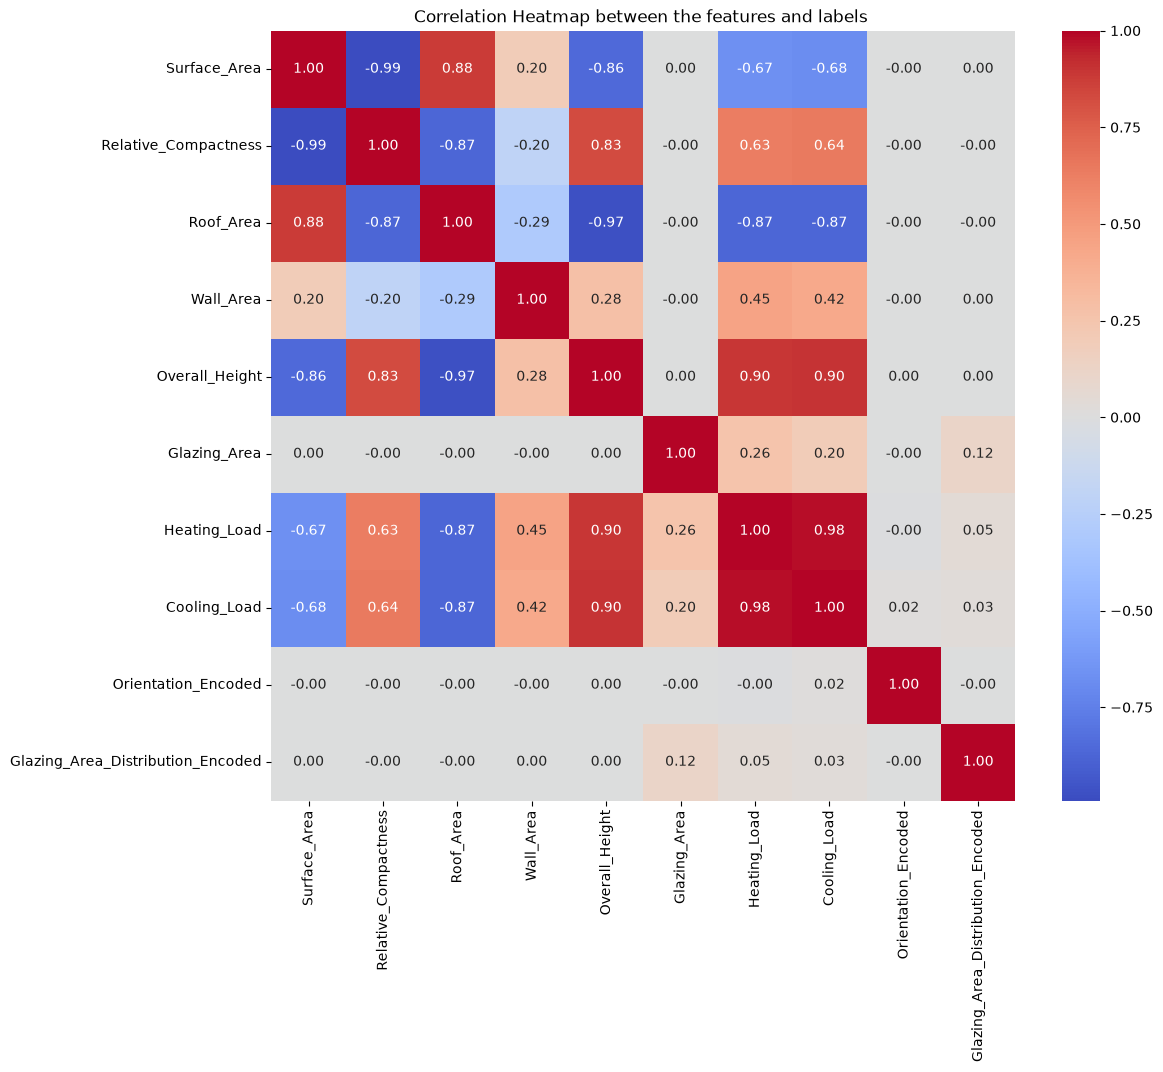

In [26]:
#############################################################

# ((((((((((((((3 Data Visualization))))))))))))))


# first a heat map to show the corrleation between columns 

# deciding the figure size
# the active figure now is heat map
plt.figure(figsize=(12,10 ))

# finding the correlation 
corr_matrix = df_encoded.corr(numeric_only=True)

sns.heatmap(corr_matrix , annot= True , cmap= 'coolwarm', fmt = '.2f' )

plt.title('Correlation Heatmap between the features and labels ')
plt.show()


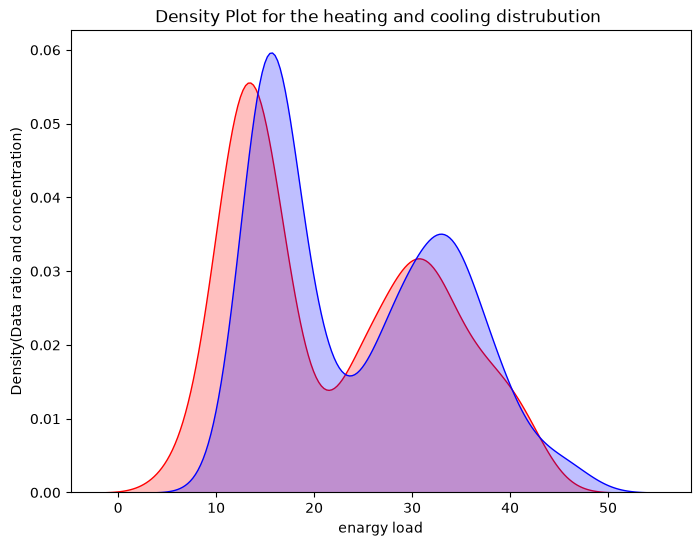

In [27]:

 # Creating the density plot

# secong visualization 

plt.figure(figsize=(8,6))

# the first density for heating 
sns.kdeplot(data = df_encoded['Heating_Load'], fill = True , color= 'red' , label = 'heating load' )
# the second density for cooling 
sns.kdeplot(data= df_encoded['Cooling_Load'], fill= True , color= 'blue' , label = 'Cooling Load')

plt.title('Density Plot for the heating and cooling distrubution ')
plt.xlabel('enargy load')
plt.ylabel('Density(Data ratio and concentration)')
plt.show()

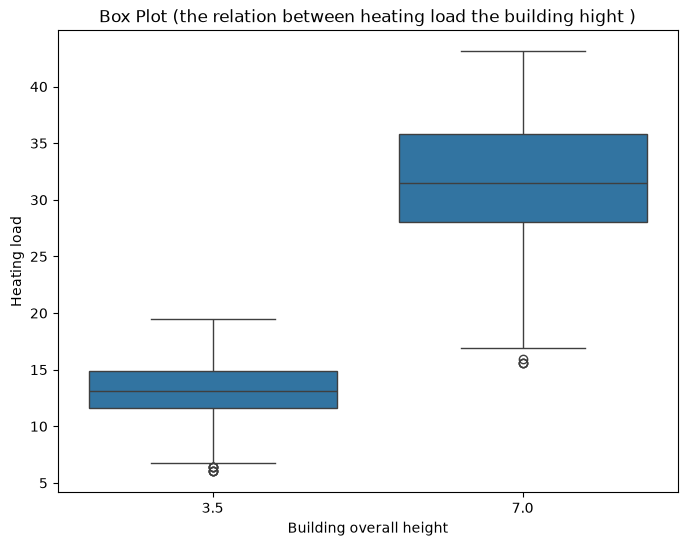

In [28]:

# The box plot 
# shows the relation between the hight and the heating load 

plt.figure(figsize= (8,6))

sns.boxplot(x= 'Overall_Height' , y= 'Heating_Load' , data= df_encoded)


plt.title('Box Plot (the relation between heating load the building hight )')
plt.xlabel('Building overall height')
plt.ylabel('Heating load')

plt.show()

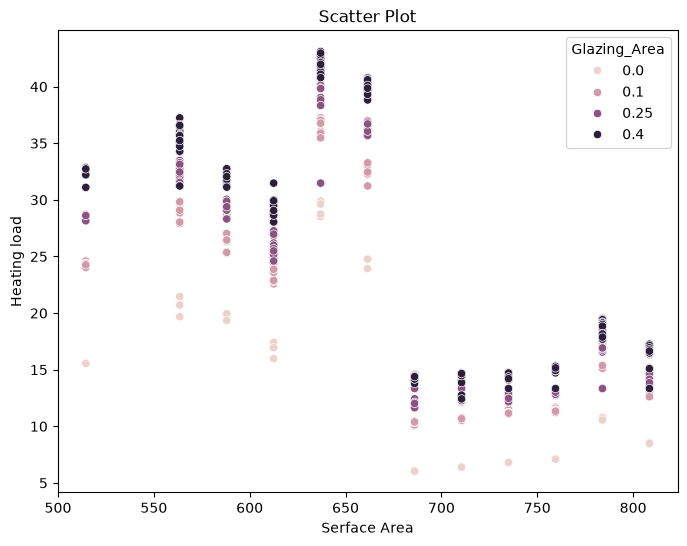

In [29]:


# Scatter Plot , (we will use hue)
# using hue will help us compairing between 3 different variables rather than 2 

# it will fing the connection between both (serface Area and Glazing Area ) and Heating load 

plt.figure(figsize=(8,6))

sns.scatterplot(data= df_encoded , x= 'Surface_Area' , y= 'Heating_Load' , hue= 'Glazing_Area')

plt.title('Scatter Plot')

plt.xlabel('Serface Area')
plt.ylabel('Heating load')


plt.show()


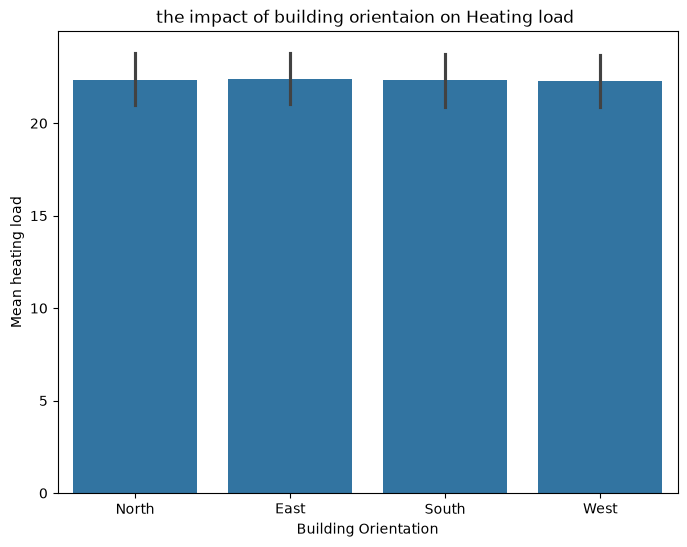

In [30]:

# the fifth visualization figure 

# Bar Plot 

# finding the impact of building orientaion on Heating load 

plt.figure(figsize=(8,6))

sns.barplot(data=df_copy, x='Orientation', y='Heating_Load')

plt.title('the impact of building orientaion on Heating load ')
plt.xlabel('Building Orientation')
plt.ylabel('Mean heating load')

plt.show()
